# Лабораторная работа 2: Дивергенции как инструмент отладки GAN

**Проект:** GAN (`/Users/macpro/PycharmProjects/GAN`)  
**Тема:** Исследование дивергенций Кульбака — Лейблера ($D_{KL}$), Йенсена — Шеннона ($D_{JS}$) и расстояния Вассерштейна ($W$) для понимания динамики обучения генеративно-состязательных сетей (GAN).

---

## Цели и задачи работы:
1. **Задача 1. KL vs JS: где ломается KL:**
   - Исследовать поведение $D_{KL}(P \parallel Q)$, $D_{KL}(Q \parallel P)$ и $D_{JS}(P \parallel Q)$ на дискретных распределениях с нулевыми исходами.
   - Показать асимметрию KL и причину расходимости к $+\infty$.
   - Доказать ограниченность $D_{JS} \le \ln 2 \approx 0.693$.
2. **Задача 2. Проблема носителей: почему GAN не учится:**
   - Смоделировать два 2D облака точек из гауссовых распределений.
   - Оценить $D_{JS}$ через сетку дискретизации $100 \times 100$ при постепенном сближении центров от $d=6$ до $d=0$.
   - Продемонстрировать плато $\ln 2$ с нулевым градиентом (vanishing gradient problem) при непересекающихся носителях.
3. **Задача 3. Wasserstein vs KL vs JS: сравнение на одном графике:**
   - Сравнить три метрики для 1D нормальных распределений при изменении сдвига среднего $\mu \in [0, 10]$.
   - Построить кривые: квадратичную ($D_{KL} = \frac{\mu^2}{2}$), насыщающуюся ($D_{JS} \to \ln 2$) и линейную ($W = \mu$).
   - Обосновать превосходство метрики Вассерштейна для обучения генераторов (WGAN).


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import quad
import pandas as pd

# Эстетика графиков
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#bbbbbb'
plt.rcParams['axes.linewidth'] = 0.9

print("Все библиотеки успешно загружены!")


Все библиотеки успешно загружены!


---
# ЗАДАЧА 1. KL vs JS: где ломается KL

### 1. Теоретическая справка
**Дивергенция Кульбака — Лейблера (KL divergence):**
$$D_{KL}(P \parallel Q) = \sum_{x} P(x) \ln \frac{P(x)}{Q(x)}$$
- Свойства:
  1. $D_{KL}(P \parallel Q) \ge 0$, равенство достигается тогда и только тогда, когда $P = Q$.
  2. **Асимметрична:** $D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)$.
  3. **Проблема нулевой вероятности:** если существует $x$ такой, что $P(x) > 0$, но $Q(x) = 0$, то $\frac{P(x)}{Q(x)} \to \infty \implies D_{KL}(P \parallel Q) = +\infty$.

**Дивергенция Йенсена — Шеннона (JS divergence):**
Пусть $M = \frac{1}{2}(P + Q)$ — средняя смесь распределений.
$$D_{JS}(P \parallel Q) = \frac{1}{2} D_{KL}(P \parallel M) + \frac{1}{2} D_{KL}(Q \parallel M)$$
- Свойства:
  1. **Симметрична:** $D_{JS}(P \parallel Q) = D_{JS}(Q \parallel P)$.
  2. **Всегда конечна и строго ограничена:** $0 \le D_{JS}(P \parallel Q) \le \ln(2) \approx 0.69315$.
  3. Носитель $M(x) = 0.5(P(x) + Q(x))$ положителен везде, где положителен хотя бы один из $P(x)$ или $Q(x)$, что полностью устраняет деление на ноль!


,Шаг,t,Q(x),D_KL(P||Q),D_KL(Q||P),D_JS(P||Q)
0,0,0.0,"[0.0, 0.1, 0.2, 0.3, 0.4]",∞ (inf),∞ (inf),0.3296
1,1,0.2,"[0.08, 0.14, 0.2, 0.26, 0.32]",0.776866,∞ (inf),0.2024
2,2,0.4,"[0.16, 0.18, 0.2, 0.22, 0.24]",0.440918,∞ (inf),0.1289
3,3,0.6,"[0.24, 0.22, 0.2, 0.18, 0.16]",0.238598,∞ (inf),0.0744
4,4,0.8,"[0.32, 0.26, 0.2, 0.14, 0.08]",0.09854,∞ (inf),0.0323
5,5,1.0,"[0.4, 0.3, 0.2, 0.1, 0.0]",0.0,0.0,0.0000


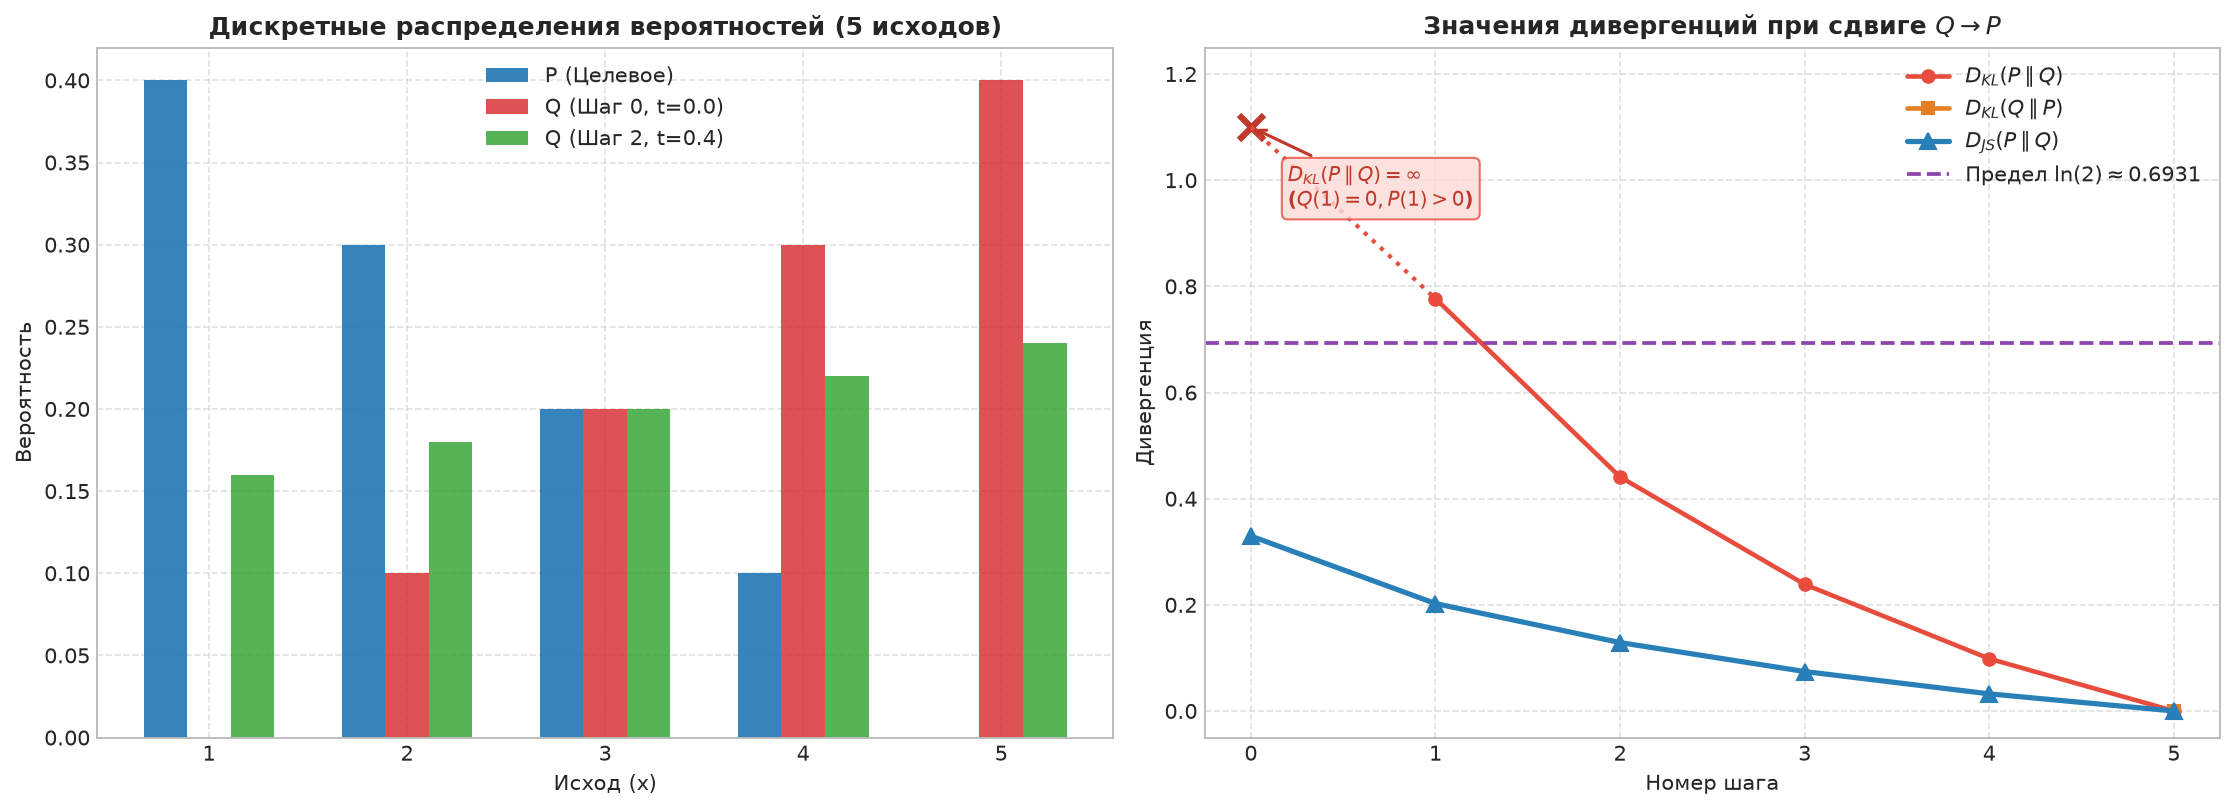

In [2]:
# 1. Задаем исходные дискретные распределения
P = np.array([0.4, 0.3, 0.2, 0.1, 0.0])
Q = np.array([0.0, 0.1, 0.2, 0.3, 0.4])

def kl_divergence_discrete(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    zero_q_mask = (p > 0) & (q == 0)
    if np.any(zero_q_mask):
        return np.inf
    nz = p > 0
    return float(np.sum(p[nz] * np.log(p[nz] / q[nz])))

def js_divergence_discrete(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    m = 0.5 * (p + q)
    nz_p, nz_q = p > 0, q > 0
    kl_p_m = np.sum(p[nz_p] * np.log(p[nz_p] / m[nz_p]))
    kl_q_m = np.sum(q[nz_q] * np.log(q[nz_q] / m[nz_q]))
    return float(0.5 * (kl_p_m + kl_q_m))

# Плавный сдвиг Q к P за 6 шагов (t = 0.0, 0.2, 0.4, 0.6, 0.8, 1.0)
steps = 6
t_values = np.linspace(0.0, 1.0, steps)

results_t1 = []
for i, t in enumerate(t_values):
    Q_t = (1.0 - t) * Q + t * P
    kl_pq = kl_divergence_discrete(P, Q_t)
    kl_qp = kl_divergence_discrete(Q_t, P)
    js_val = js_divergence_discrete(P, Q_t)
    results_t1.append({
        'Шаг': i,
        't': t,
        'Q(x)': np.round(Q_t, 2).tolist(),
        'D_KL(P||Q)': kl_pq if np.isfinite(kl_pq) else '∞ (inf)',
        'D_KL(Q||P)': kl_qp if np.isfinite(kl_qp) else '∞ (inf)',
        'D_JS(P||Q)': round(js_val, 4)
    })

df_t1 = pd.DataFrame(results_t1)
display(df_t1)

# Визуализация задачи 1
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=150)

# Гистограммы распределений
outcomes = np.arange(1, 6)
width = 0.22
axes[0].bar(outcomes - width, P, width=width, label='P (Целевое)', color='#1f77b4', alpha=0.9)
axes[0].bar(outcomes, Q, width=width, label='Q (Шаг 0, t=0.0)', color='#d62728', alpha=0.8)
axes[0].bar(outcomes + width, (0.6*Q + 0.4*P), width=width, label='Q (Шаг 2, t=0.4)', color='#2ca02c', alpha=0.8)
axes[0].set_title('Дискретные распределения вероятностей (5 исходов)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Исход (x)')
axes[0].set_ylabel('Вероятность')
axes[0].set_xticks(outcomes)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# График дивергенций
steps_arr = np.arange(steps)
kl_pq_nums = [r['D_KL(P||Q)'] if r['D_KL(P||Q)'] != '∞ (inf)' else np.nan for r in results_t1]
kl_qp_nums = [r['D_KL(Q||P)'] if r['D_KL(Q||P)'] != '∞ (inf)' else np.nan for r in results_t1]
js_nums = [r['D_JS(P||Q)'] for r in results_t1]

axes[1].plot(steps_arr[1:], kl_pq_nums[1:], 'o-', color='#e74c3c', linewidth=2.2, label=r'$D_{KL}(P \parallel Q)$')
axes[1].plot(steps_arr[1:], kl_qp_nums[1:], 's-', color='#e67e22', linewidth=2.2, label=r'$D_{KL}(Q \parallel P)$')
axes[1].plot(steps_arr, js_nums, '^-', color='#2980b9', linewidth=2.5, markersize=8, label=r'$D_{JS}(P \parallel Q)$')

# Отображение точки inf на шаге 0
axes[1].plot([0], [1.1], marker='x', markersize=12, markeredgewidth=3, color='#c0392b')
axes[1].plot([0, 1], [1.1, kl_pq_nums[1]], ':', color='#e74c3c', linewidth=2)
axes[1].annotate(r'$D_{KL}(P \parallel Q) = \infty$' + '\n($Q(1)=0, P(1)>0$)',
                 xy=(0, 1.1), xytext=(0.2, 0.95),
                 arrowprops=dict(arrowstyle="->", color='#c0392b', lw=1.5),
                 fontsize=9.5, fontweight='bold', color='#c0392b',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#fadbd8", ec="#e74c3c", alpha=0.8))

axes[1].axhline(np.log(2.0), color='#8e44ad', linestyle='--', linewidth=1.8, label=r'Предел $\ln(2) \approx 0.6931$')
axes[1].set_title(r'Значения дивергенций при сдвиге $Q \to P$', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Номер шага')
axes[1].set_ylabel('Дивергенция')
axes[1].set_xticks(steps_arr)
axes[1].set_ylim(-0.05, 1.25)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Выводы по Задаче 1 («Что понять»):
1. **Разрушение $D_{KL}$ из-за нулей:**
   - На шаге 0 в исходе $x=1$: $P(1) = 0.4 > 0$, но $Q(1) = 0.0$. Член формулы $0.4 \cdot \ln\left(\frac{0.4}{0.0}\right) = +\infty$. Дивергенция моментально взрывается.
   - Более того, для $D_{KL}(Q \parallel P)$ на исходе $x=5$: $Q(5) = 0.4 > 0$, но $P(5) = 0.0$. Поэтому $D_{KL}(Q \parallel P) = +\infty$ на всех шагах от 0 до 4, пока $Q_t(5) > 0$.
2. **Стабильность $D_{JS}$:**
   - $D_{JS}(P \parallel Q)$ всегда конечна, гладка и строго ограничена константой $\ln 2 \approx 0.6931$.
3. **Практический вывод для GAN:**
   - Дивергенцию KL **нельзя** использовать напрямую как функцию потерь генеративных моделей, если распределение генератора не покрывает весь носитель реальных данных: любое несовпадение носителей приводит к делению на ноль и аварийному взрыву градиентов (NaN / $\infty$).


---
# ЗАДАЧА 2. Проблема носителей: почему GAN не учится

### 1. Теоретическая основа и гипотеза многообразий
В классическом GAN (Goodfellow et al., 2014) доказано, что при оптимальном дискриминаторе $D^*(x) = \frac{p_r(x)}{p_r(x) + p_g(x)}$ целевая функция генератора эквивалентна минимизации дивергенции Йенсена — Шеннона:
$$\mathcal{L}(G) = 2 \cdot D_{JS}(P_r \parallel P_g) - 2\ln 2$$
Однако реальные данные (например, изображения) лежат на низкоразмерных подмногообразиях высокой размерности (Manifold Hypothesis).
Если носители распределений $\mathrm{supp}(P)$ и $\mathrm{supp}(Q)$ не пересекаются (или пересекаются по множеству меры ноль):
$$D_{JS}(P \parallel Q) = \ln 2 \approx 0.69315 = \mathrm{const}$$
Следовательно, градиент по параметрам генератора $\theta$:
$$\nabla_\theta D_{JS}(P_r \parallel P_\theta) = \nabla_\theta (\ln 2) = 0$$
**Генератор не получает никакого обучающего сигнала (Vanishing Gradient)!**


,Шаг,Центр Q,Расстояние d,JS (по точкам),JS (теоретич.)
0,0,"(3.00, 0.00)",6.0,0.6900,0.6893
1,1,"(2.40, 0.00)",5.4,0.6828,0.6834
2,2,"(1.80, 0.00)",4.8,0.6671,0.6706
3,3,"(1.20, 0.00)",4.2,0.6368,0.6452
4,4,"(0.60, 0.00)",3.6,0.5857,0.5998
5,5,"(0.00, 0.00)",3.0,0.5075,0.5268
6,6,"(-0.60, 0.00)",2.4,0.4009,0.4221
7,7,"(-1.20, 0.00)",1.8,0.2728,0.2911
8,8,"(-1.80, 0.00)",1.2,0.1421,0.1532
9,9,"(-2.40, 0.00)",0.6,0.0415,0.0431


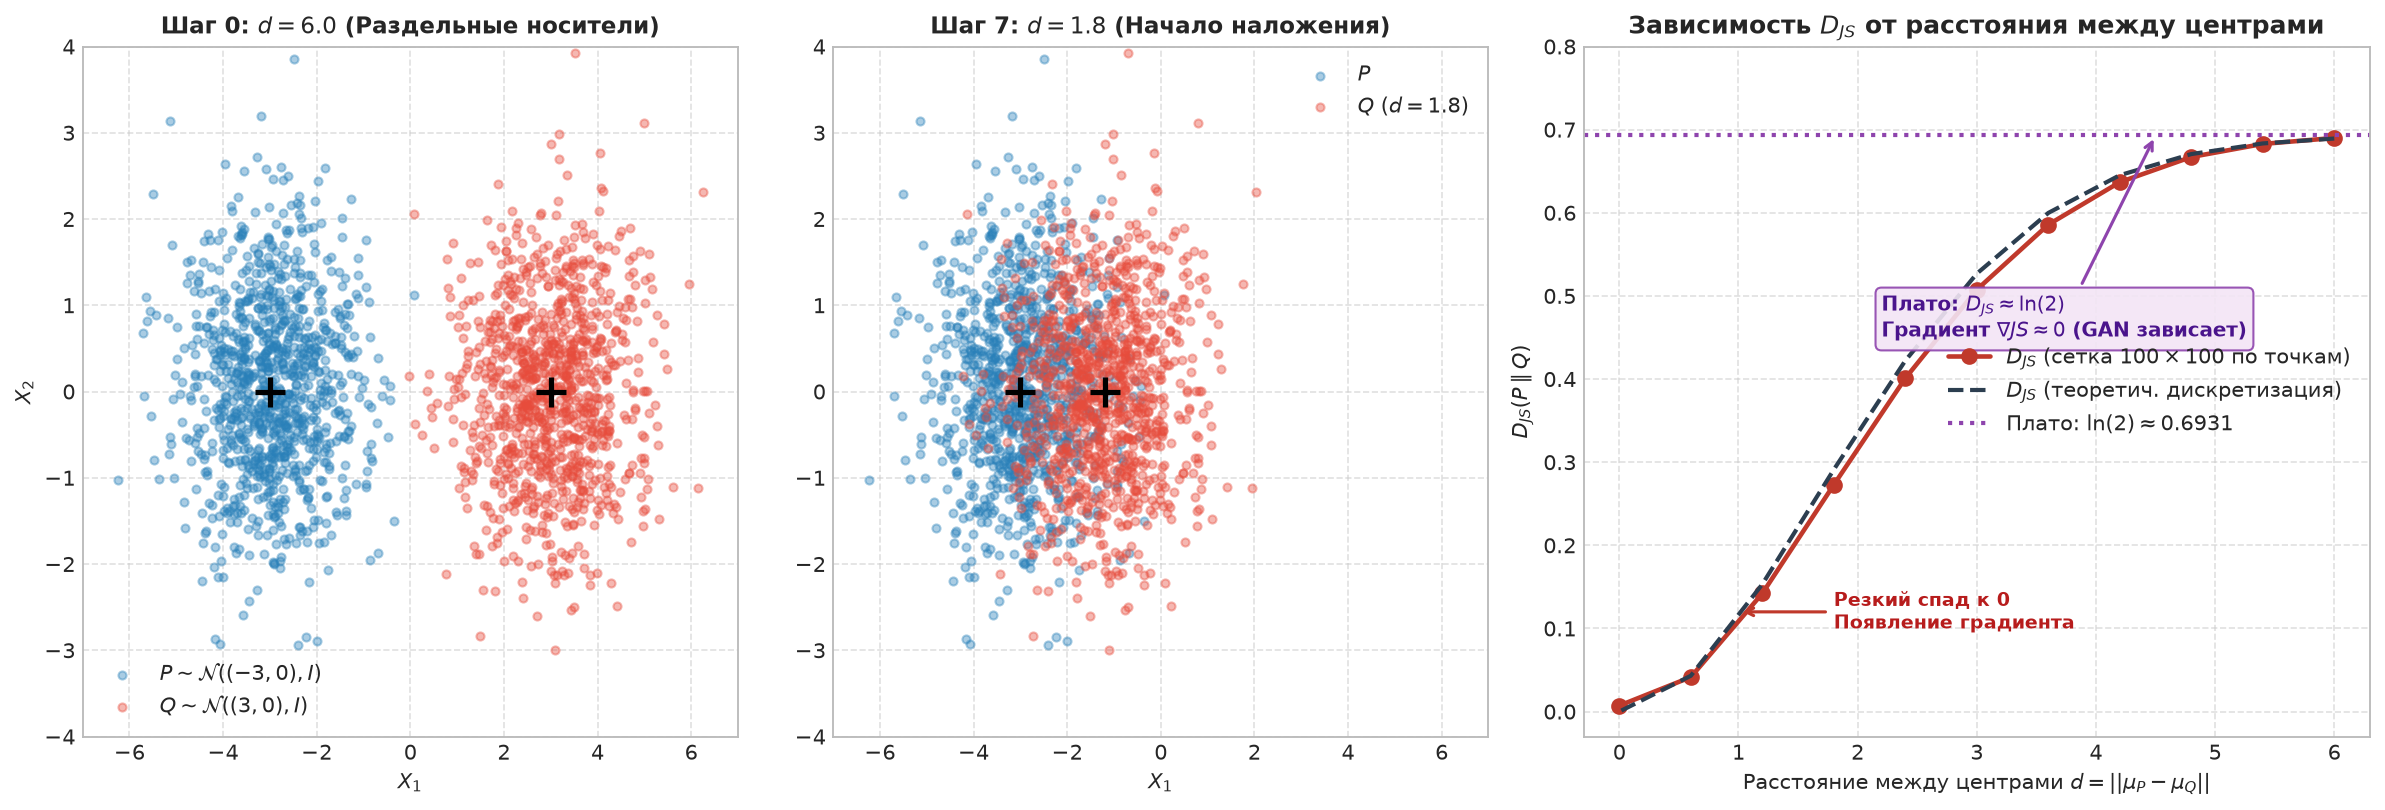

In [3]:
np.random.seed(42)
n_points = 1000

# P ~ N((-3, 0), I)
mean_P = np.array([-3.0, 0.0])
cov_I = np.eye(2)
data_P = np.random.multivariate_normal(mean_P, cov_I, size=n_points)

# Сетка 100x100 в границах x in [-7, 7], y in [-4, 4]
grid_size = 100
x_lin = np.linspace(-7.0, 7.0, grid_size)
y_lin = np.linspace(-4.0, 4.0, grid_size)
X, Y = np.meshgrid(x_lin, y_lin)
grid_coords = np.vstack([X.ravel(), Y.ravel()])

# Плотность P на сетке
kde_P = stats.gaussian_kde(data_P.T)
prob_P_kde = kde_P(grid_coords).reshape(grid_size, grid_size)
prob_P_kde /= np.sum(prob_P_kde)

dens_P_theor = np.exp(-0.5 * ((X - mean_P[0])**2 + (Y - mean_P[1])**2))
prob_P_theor = dens_P_theor / np.sum(dens_P_theor)

# Базовые точки для Q
base_points_Q = np.random.multivariate_normal([0.0, 0.0], cov_I, size=n_points)

num_steps = 11
shift_ratios = np.linspace(0.0, 1.0, num_steps)

results_t2 = []
for step_idx, ratio in enumerate(shift_ratios):
    current_center_Q = (1.0 - ratio) * np.array([3.0, 0.0]) + ratio * mean_P
    dist = float(np.linalg.norm(current_center_Q - mean_P))

    data_Q = base_points_Q + current_center_Q
    kde_Q = stats.gaussian_kde(data_Q.T)
    prob_Q_kde = kde_Q(grid_coords).reshape(grid_size, grid_size)
    prob_Q_kde /= np.sum(prob_Q_kde)

    # Вычисление JS по выборке
    prob_M_kde = 0.5 * (prob_P_kde + prob_Q_kde)
    kl_p_k = np.sum(prob_P_kde * np.log(prob_P_kde / prob_M_kde))
    kl_q_k = np.sum(prob_Q_kde * np.log(prob_Q_kde / prob_M_kde))
    js_sample = float(0.5 * (kl_p_k + kl_q_k))

    # Вычисление теоретического JS на сетке
    dens_Q_theor = np.exp(-0.5 * ((X - current_center_Q[0])**2 + (Y - current_center_Q[1])**2))
    prob_Q_theor = dens_Q_theor / np.sum(dens_Q_theor)
    prob_M_theor = 0.5 * (prob_P_theor + prob_Q_theor)
    kl_p_t = np.sum(prob_P_theor * np.log(prob_P_theor / prob_M_theor))
    kl_q_t = np.sum(prob_Q_theor * np.log(prob_Q_theor / prob_M_theor))
    js_theor = float(0.5 * (kl_p_t + kl_q_t))

    results_t2.append({
        'Шаг': step_idx,
        'Центр Q': f"({current_center_Q[0]:.2f}, {current_center_Q[1]:.2f})",
        'Расстояние d': round(dist, 2),
        'JS (по точкам)': round(js_sample, 4),
        'JS (теоретич.)': round(js_theor, 4)
    })

df_t2 = pd.DataFrame(results_t2)
display(df_t2)

# Визуализация задачи 2
fig = plt.figure(figsize=(16, 5.5), dpi=150)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# Панель 1: d = 6.0
ax1 = fig.add_subplot(gs[0])
ax1.scatter(data_P[:, 0], data_P[:, 1], color='#2980b9', alpha=0.4, s=15, label=r'$P \sim \mathcal{N}((-3, 0), I)$')
data_Q_start = base_points_Q + np.array([3.0, 0.0])
ax1.scatter(data_Q_start[:, 0], data_Q_start[:, 1], color='#e74c3c', alpha=0.4, s=15, label=r'$Q \sim \mathcal{N}((3, 0), I)$')
ax1.plot([-3], [0], 'k+', markersize=14, markeredgewidth=2.5)
ax1.plot([3], [0], 'k+', markersize=14, markeredgewidth=2.5)
ax1.set_xlim(-7, 7)
ax1.set_ylim(-4, 4)
ax1.set_title(r'Шаг 0: $d=6.0$ (Раздельные носители)', fontsize=11, fontweight='bold')
ax1.set_xlabel('$X_1$')
ax1.set_ylabel('$X_2$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Панель 2: d = 1.8
ax2 = fig.add_subplot(gs[1])
ax2.scatter(data_P[:, 0], data_P[:, 1], color='#2980b9', alpha=0.4, s=15, label=r'$P$')
data_Q_mid = base_points_Q + np.array([-1.2, 0.0])
ax2.scatter(data_Q_mid[:, 0], data_Q_mid[:, 1], color='#e74c3c', alpha=0.4, s=15, label=r'$Q$ ($d=1.8$)')
ax2.plot([-3], [0], 'k+', markersize=14, markeredgewidth=2.5)
ax2.plot([-1.2], [0], 'k+', markersize=14, markeredgewidth=2.5)
ax2.set_xlim(-7, 7)
ax2.set_ylim(-4, 4)
ax2.set_title(r'Шаг 7: $d=1.8$ (Начало наложения)', fontsize=11, fontweight='bold')
ax2.set_xlabel('$X_1$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Панель 3: Расстояние vs JS
ax3 = fig.add_subplot(gs[2])
d_arr = [r['Расстояние d'] for r in results_t2]
js_sample_arr = [r['JS (по точкам)'] for r in results_t2]
js_theor_arr = [r['JS (теоретич.)'] for r in results_t2]

ax3.plot(d_arr, js_sample_arr, 'o-', color='#c0392b', linewidth=2.2, markersize=7, label=r'$D_{JS}$ (сетка $100 \times 100$ по точкам)')
ax3.plot(d_arr, js_theor_arr, '--', color='#2c3e50', linewidth=2.0, label=r'$D_{JS}$ (теоретич. дискретизация)')
ax3.axhline(np.log(2.0), color='#8e44ad', linestyle=':', linewidth=2, label=r'Плато: $\ln(2) \approx 0.6931$')

ax3.annotate(r'Плато: $D_{JS} \approx \ln(2)$' + '\n' + r'Градиент $\nabla JS \approx 0$ (GAN зависает)',
             xy=(4.5, np.log(2.0)), xytext=(2.2, 0.45),
             arrowprops=dict(arrowstyle="->", color='#8e44ad', lw=1.5),
             fontsize=9.5, fontweight='bold', color='#4a148c',
             bbox=dict(boxstyle="round,pad=0.3", fc="#f3e5f5", ec="#8e44ad", alpha=0.9))

ax3.annotate('Резкий спад к 0\nПоявление градиента',
             xy=(1.0, 0.12), xytext=(1.8, 0.1),
             arrowprops=dict(arrowstyle="->", color='#c0392b', lw=1.5),
             fontsize=9, fontweight='bold', color='#b71c1c')

ax3.set_title(r'Зависимость $D_{JS}$ от расстояния между центрами', fontsize=12, fontweight='bold')
ax3.set_xlabel(r'Расстояние между центрами $d = ||\mu_P - \mu_Q||$')
ax3.set_ylabel(r'$D_{JS}(P \parallel Q)$')
ax3.set_ylim(-0.03, 0.8)
ax3.legend(loc='center right')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Выводы по Задаче 2 («Что понять»):
1. **Плато константы $\ln 2$:** При расстояниях $d \ge 4.5$ облака точек практически не пересекаются в пространстве. Значение $D_{JS}$ строго держится около константы $\ln(2) \approx 0.6931$.
2. **Исчезновение градиента (Vanishing Gradient):**
   - На плато производная $\frac{\partial D_{JS}}{\partial d} \approx 0$.
   - Дискриминатор моментально разделяет реальные и сгенерированные данные со 100% уверенностью ($D(x) = 1$ для $P$, $D(x) = 0$ для $Q$). Градиенты, текущие в генератор, зануляются.
3. **Глобальный вывод:**
   - В реальных задачах машинного обучения размерность данных $D$ огромна (например, для картинок $64 \times 64 \times 3$ размерность $D = 12\,288$). В таких сверхвысоких размерностях непересечение многообразий гарантировано с вероятностью 1! Классический GAN с JS-лоссом не обучается без тщательного подбора эвристик. **Необходима метрика, дающая непрерывный градиент даже при непересекающихся носителях — расстояние Вассерштейна.**


---
# ЗАДАЧА 3. Wasserstein vs KL vs JS: сравнение на одном графике

### 1. Формулы для одномерных нормальных распределений
Пусть $P = \mathcal{N}(0, 1)$ и $Q = \mathcal{N}(\mu, 1)$, где $\mu \in [0, 10]$.

1. **Дивергенция KL (аналитическая формула):**
   $$D_{KL}(P \parallel Q) = \ln \frac{\sigma_Q}{\sigma_P} + \frac{\sigma_P^2 + (\mu_P - \mu_Q)^2}{2\sigma_Q^2} - \frac{1}{2}$$
   Подставляя $\mu_P = 0, \sigma_P = 1, \mu_Q = \mu, \sigma_Q = 1$:
   $$D_{KL}(P \parallel Q) = \ln 1 + \frac{1 + (0 - \mu)^2}{2 \cdot 1} - \frac{1}{2} = \frac{\mu^2}{2}$$
   *Квадратичный рост:* градиент $\nabla_\mu D_{KL} = \mu$ растет неограниченно, приводя к взрыву градиентов (exploding gradients).

2. **Дивергенция JS (численный расчет):**
   $$D_{JS}(P \parallel Q) = \frac{1}{2} \int_{-\infty}^\infty p(x) \ln \frac{2p(x)}{p(x)+q(x)} dx + \frac{1}{2} \int_{-\infty}^\infty q(x) \ln \frac{2q(x)}{p(x)+q(x)} dx$$
   *Насыщение:* при $\mu \ge 4$ значение упирается в $\ln 2 \approx 0.69315$, а градиент $\nabla_\mu D_{JS} \to 0$.

3. **Расстояние Вассерштейна (Wasserstein-2 Distance):**
   Для одномерных гауссианов аналитическая формула имеет вид:
   $$W(P, Q) = \sqrt{(\mu_P - \mu_Q)^2 + (\sigma_P - \sigma_Q)^2} = \sqrt{(0 - \mu)^2 + (1 - 1)^2} = \sqrt{\mu^2} = \mu$$
   *Строго линейный рост:* градиент $\nabla_\mu W = 1 = \mathrm{const}$ всегда, при любом удалении распределений!


,μ,KL (μ²/2),JS (численно),Wasserstein (μ)
0,0.0,0.0,0.0000,0.0
1,1.0,0.5,0.1114,1.0
2,3.0,4.5,0.5268,3.0
3,5.0,12.5,0.6759,5.0
4,10.0,50.0,0.6931,10.0


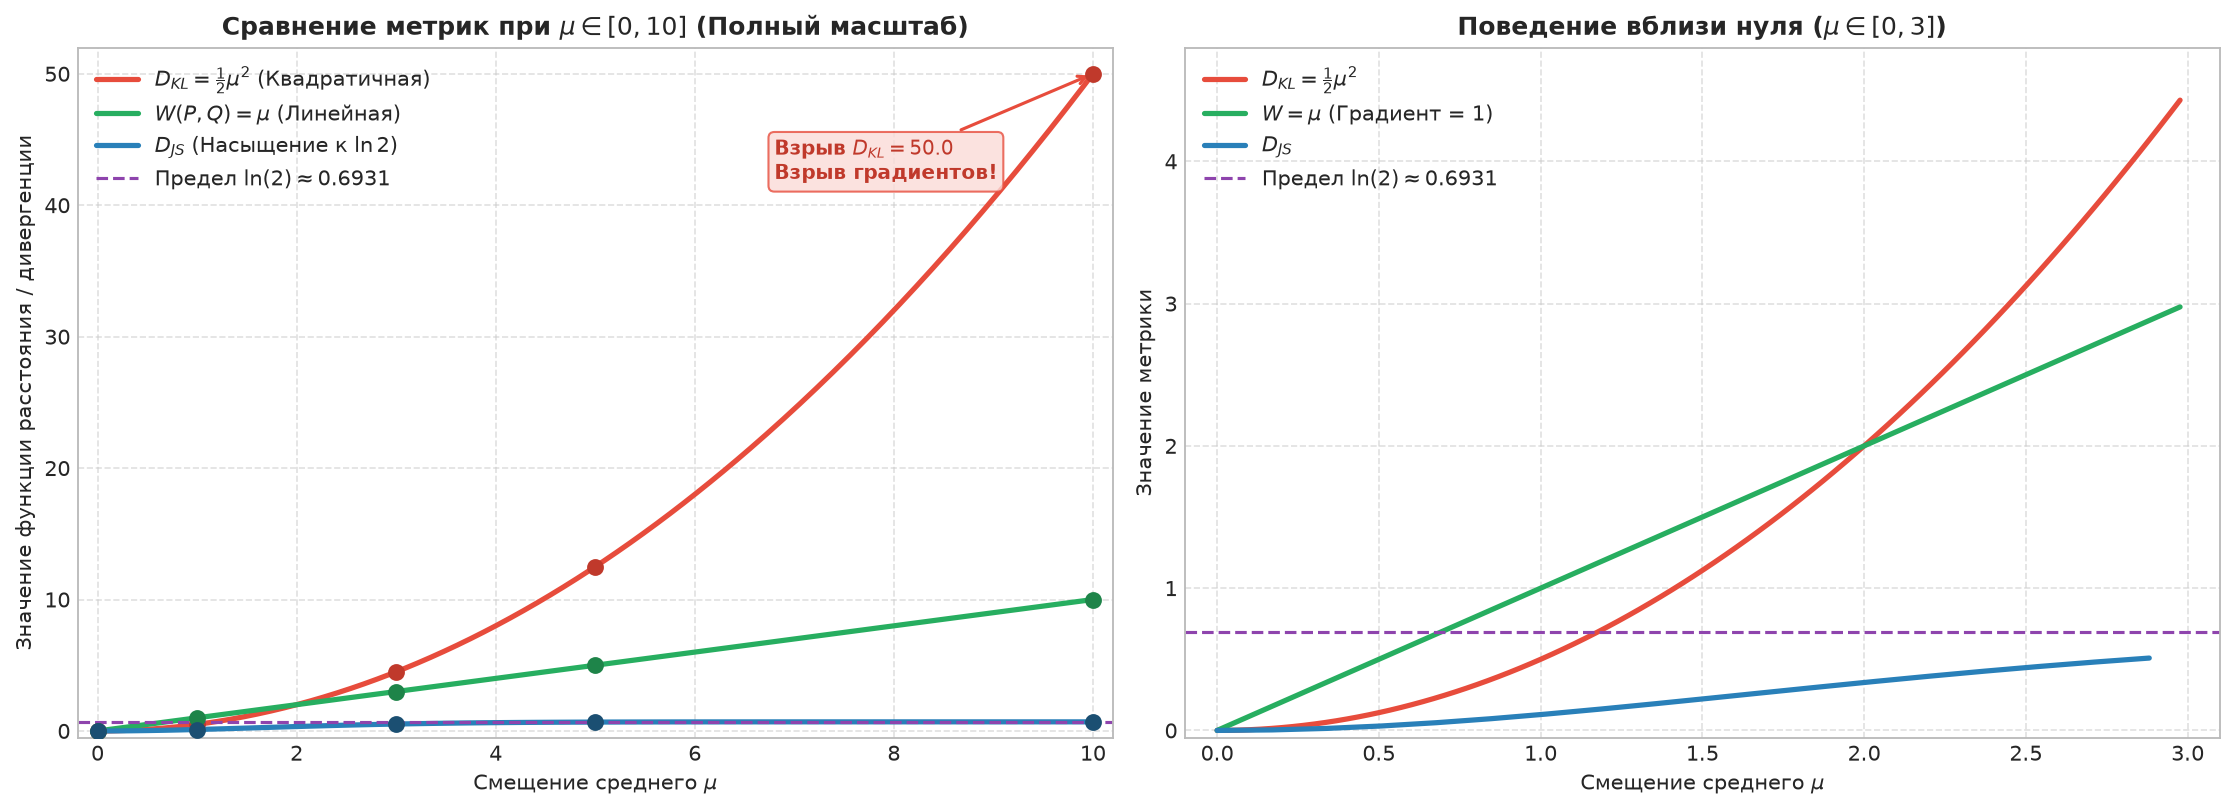

In [4]:
mu_dense = np.linspace(0.0, 10.0, 300)

# 1. Аналитический KL
kl_values_dense = 0.5 * (mu_dense ** 2)

# 2. Wasserstein
w_values_dense = mu_dense.copy()

# 3. Численный JS
def compute_js_gaussian_1d(mu_val):
    if abs(mu_val) < 1e-12:
        return 0.0
    p = lambda x: stats.norm.pdf(x, loc=0.0, scale=1.0)
    q = lambda x: stats.norm.pdf(x, loc=mu_val, scale=1.0)
    m = lambda x: 0.5 * (p(x) + q(x))
    integrand_p = lambda x: p(x) * np.log(np.maximum(p(x) / m(x), 1e-25))
    integrand_q = lambda x: q(x) * np.log(np.maximum(q(x) / m(x), 1e-25))
    x_min, x_max = min(0.0, mu_val) - 6.0, max(0.0, mu_val) + 6.0
    val_p, _ = quad(integrand_p, x_min, x_max, limit=200)
    val_q, _ = quad(integrand_q, x_min, x_max, limit=200)
    return float(0.5 * (val_p + val_q))

mu_js_sample = np.linspace(0.0, 10.0, 60)
js_sample = np.array([compute_js_gaussian_1d(m) for m in mu_js_sample])

# Таблица для контрольных точек mu in {0, 1, 3, 5, 10}
control_mus = [0.0, 1.0, 3.0, 5.0, 10.0]
results_t3 = []
for m in control_mus:
    results_t3.append({
        'μ': m,
        'KL (μ²/2)': round(0.5 * (m ** 2), 4),
        'JS (численно)': round(compute_js_gaussian_1d(m), 4),
        'Wasserstein (μ)': round(m, 4)
    })

df_t3 = pd.DataFrame(results_t3)
display(df_t3)

# Построение графика сравнения трех метрик
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=150)

# Левый график: полный обзор до mu = 10
ax1.plot(mu_dense, kl_values_dense, '-', color='#e74c3c', linewidth=2.5, label=r'$D_{KL} = \frac{1}{2}\mu^2$ (Квадратичная)')
ax1.plot(mu_dense, w_values_dense, '-', color='#27ae60', linewidth=2.5, label=r'$W(P, Q) = \mu$ (Линейная)')
ax1.plot(mu_js_sample, js_sample, '-', color='#2980b9', linewidth=2.5, label=r'$D_{JS}$ (Насыщение к $\ln 2$)')

# Точки таблицы
ctrl_m = np.array(control_mus)
ax1.scatter(ctrl_m, 0.5 * (ctrl_m ** 2), color='#c0392b', s=50, zorder=5)
ax1.scatter(ctrl_m, ctrl_m, color='#1e8449', s=50, zorder=5)
ax1.scatter(ctrl_m, [r['JS (численно)'] for r in results_t3], color='#1b4f72', s=50, zorder=5)

ax1.axhline(np.log(2.0), color='#8e44ad', linestyle='--', linewidth=1.5, label=r'Предел $\ln(2) \approx 0.6931$')
ax1.set_title(r'Сравнение метрик при $\mu \in [0, 10]$ (Полный масштаб)', fontsize=12, fontweight='bold')
ax1.set_xlabel(r'Смещение среднего $\mu$')
ax1.set_ylabel('Значение функции расстояния / дивергенции')
ax1.set_ylim(-0.5, 52)
ax1.set_xlim(-0.2, 10.2)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

ax1.annotate(r'Взрыв $D_{KL} = 50.0$' + '\nВзрыв градиентов!',
             xy=(10.0, 50.0), xytext=(6.8, 42.0),
             arrowprops=dict(arrowstyle="->", color='#e74c3c', lw=1.5),
             fontsize=9.5, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle="round,pad=0.3", fc="#fadbd8", ec="#e74c3c", alpha=0.8))

# Правый график: Детальный масштаб вблизи нуля mu in [0, 3]
mask = mu_dense <= 3.0
ax2.plot(mu_dense[mask], kl_values_dense[mask], '-', color='#e74c3c', linewidth=2.5, label=r'$D_{KL} = \frac{1}{2}\mu^2$')
ax2.plot(mu_dense[mask], w_values_dense[mask], '-', color='#27ae60', linewidth=2.5, label=r'$W = \mu$ (Градиент = 1)')
mask_js = mu_js_sample <= 3.0
ax2.plot(mu_js_sample[mask_js], js_sample[mask_js], '-', color='#2980b9', linewidth=2.5, label=r'$D_{JS}$')
ax2.axhline(np.log(2.0), color='#8e44ad', linestyle='--', linewidth=1.5, label=r'Предел $\ln(2) \approx 0.6931$')

ax2.set_title(r'Поведение вблизи нуля ($\mu \in [0, 3]$)', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Смещение среднего $\mu$')
ax2.set_ylabel('Значение метрики')
ax2.set_ylim(-0.05, 4.8)
ax2.set_xlim(-0.1, 3.1)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Выводы по Задаче 3 («Что понять»):
1. **$D_{KL}$ растет неограниченно (квадратично):**
   - При $\mu = 10$ значение $D_{KL} = 50.0$, а градиент $\nabla_\mu D_{KL} = 10$.
   - Взрыв лосса и градиентов дестабилизирует оптимизатор и срывает обучение.
2. **$D_{JS}$ упирается в константу $\ln 2$:**
   - Уже при $\mu \ge 4$ кривая переходит в горизонтальное плато, а $\nabla_\mu D_{JS} \approx 0$.
   - Генератор перестает получать обратную связь о том, в какую сторону двигаться.
3. **$W$ растет строго линейно:**
   - При любом удалении распределений (хоть $\mu = 1$, хоть $\mu = 100$) градиент равен единице: $\nabla_\mu W = 1$.
4. **Итоговый вывод (Почему WGAN решил проблему GAN):**
   - Расстояние Вассерштейна — **единственная метрика**, пригодная для обучения генератора при любом начальном расстоянии между истинным и сгенерированным распределениями.
   - Это легло в основу статьи Arjovsky et al. (2017) *«Wasserstein GAN»*, где дискриминатор заменяется на 1-Липшицев критик (через Weight Clipping или Gradient Penalty — WGAN-GP), что полностью устранило проблему затухающих градиентов в GAN.
